<a href="https://colab.research.google.com/github/mevangelista-alvarado/semana_ingenieria_uagro_2026/blob/main/4_try_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

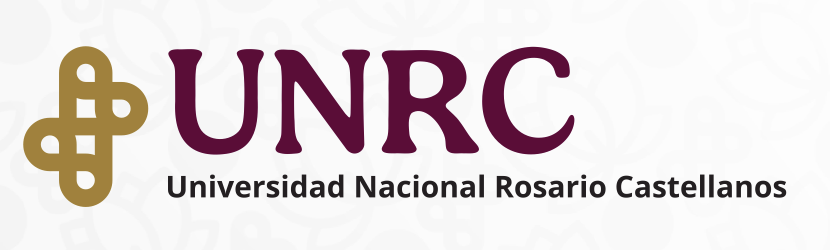

**Miguel Evangelista-Alvarado**.  
**Profesor de la Licenciatura en Ciencia de Datos para Negocios**.  
**Abril de 2026**

# Probemos el modelo

Para esto, necesitamos crear una imagen de un dígito.

## Crear la imagen

Para crear una imagen, podemos ir a https://sketch.io/sketchpad/es/

###Poner el fondo blanco

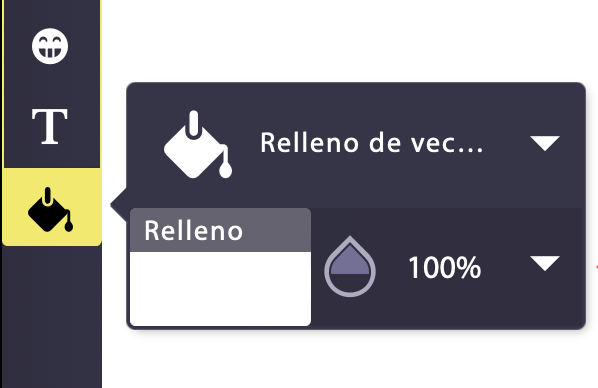

### Seleccionamos un grosor para el lápiz

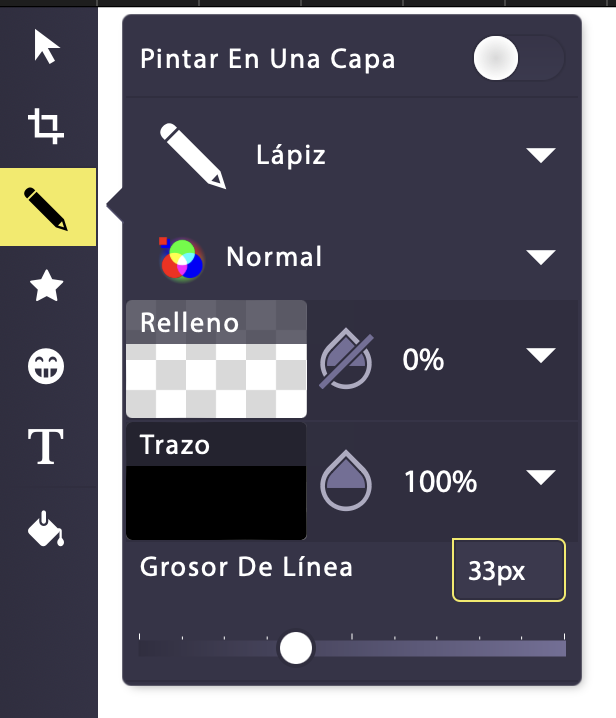

### Realizar un número, entre el 0 y 9.

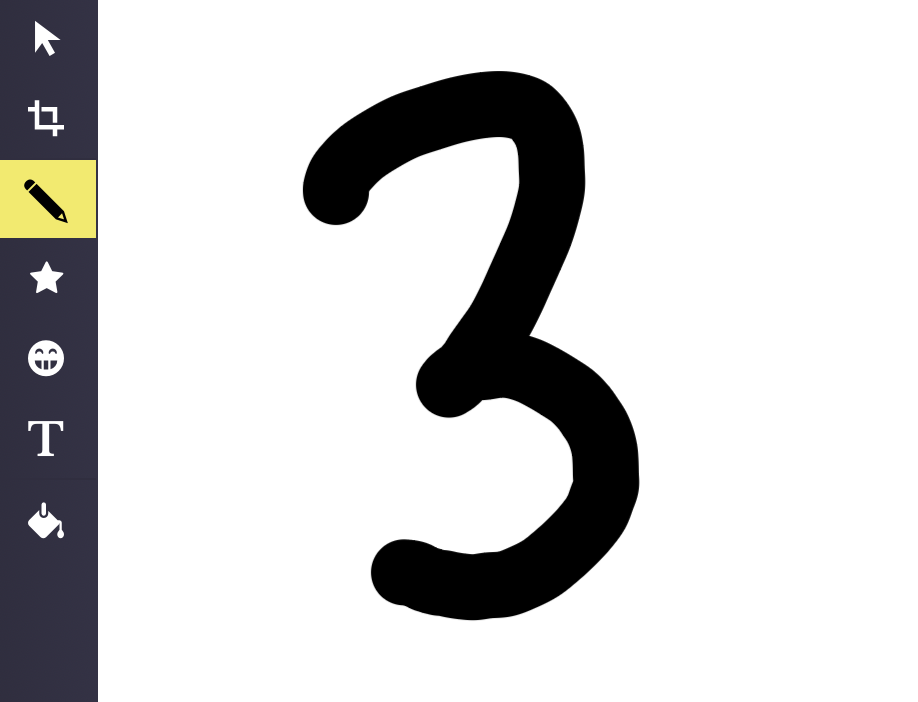



### Descargar la imagen

Click en **Export** y después en **Dowload Region**

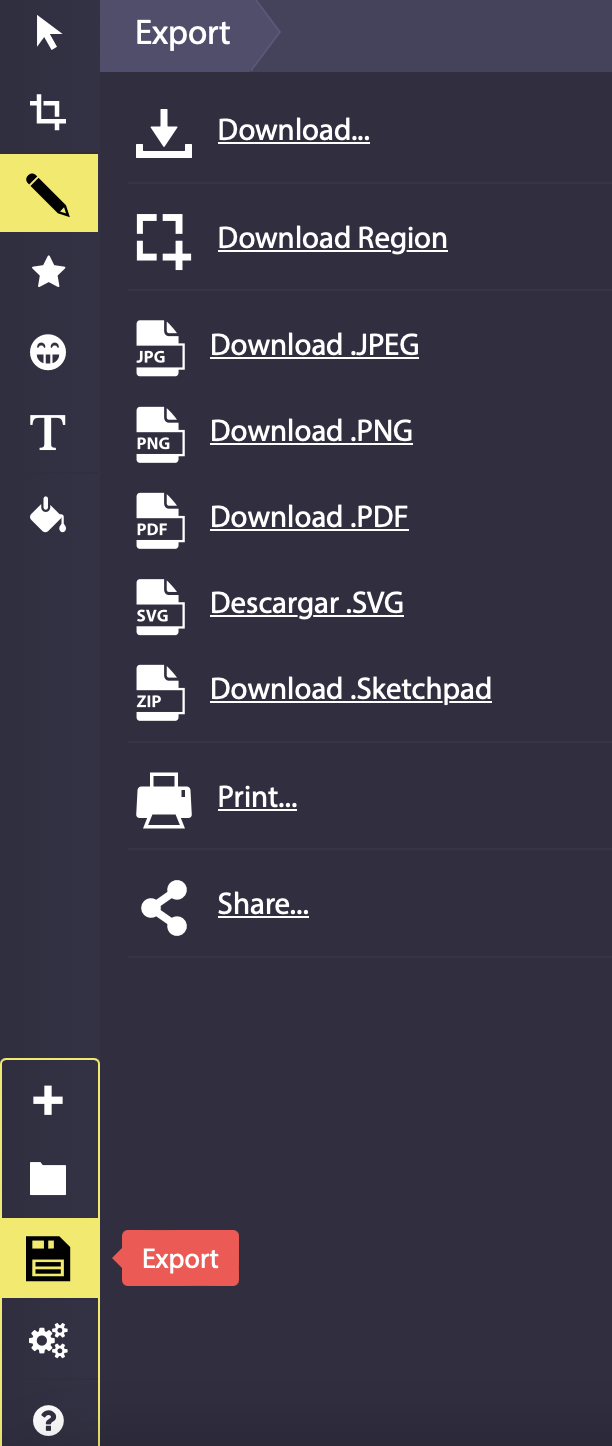

### Finalmente seleccionamos la región y se descarga la imagen

# Probamos el modelo

In [ ]:
# @title Modelo CNN
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Cargamos el modelo
print("Ingresa el modelo CNN (en formato .h5)")
uploaded = files.upload()
model_path = list(uploaded.keys())[0]
model = load_model(model_path)

# Cargamos la imagen
print("Ingresa una imagen de un dígito (en formato .png)")
uploaded = files.upload()
path_img = list(uploaded.keys())[0]


# Leemos la imagen en escala de grises
img = Image.open(path_img).convert("L")
# Mostramos la imagen
# plt.figure(figsize=(4, 4))
# plt.imshow(img)
# plt.title("Imagen original")
# plt.axis("off")
# plt.show()

# redimensionar a 8x8 (imagenes que lee nuestro modelo)
img_resized = img.resize((8, 8), Image.Resampling.LANCZOS)
# Mostramos la imagen
# plt.figure(figsize=(3, 3))
# plt.imshow(img_resized, cmap="gray")
# plt.title("Imagen redimensionada a 8x8")
# plt.axis("off")
# plt.show()

# Reescalamos de 0-255 a 0-16 e invertir (para tener imagenes
# como las que lee nuestro modelo)
# fondo negro = 0
img_array = np.array(img_resized).astype("float32")
img_array = 16 - (img_array / 255 * 16)
# Mostramos la imagen
plt.imshow(img_array, cmap="gray")
plt.title("Imagen reescalada")
plt.axis("off")
plt.show()

# Reescalamos los valores de la imagen
scaler = StandardScaler()
img_flat = img_array
img_scaled = scaler.fit_transform(img_flat)
# Dar forma (1,8,8). que es el input del modelo
img_tensor = img_scaled.reshape(1, 8, 8)

# Realizamos la predicción
pred = model.predict(img_tensor)
digit = np.argmax(pred)
print("Predicción:", digit)

### ¡Gracias!